# Pipeline B -- unsupervised hierarchical GMM + coordinate network (FLAIR + T1ce), with the items of the correction report of 09/09/2026

Run order: §A (definitions) → §B (protocol file, reference slice = Table 5.4, Figures 5.4 / 5.2 / 4.5) → §C (multi-slice journal, resumable, with two ablations) → §D (Tables 5.5 / 5.7, n_eff per class, bimodality histogram, cost) → §E (threshold sensitivity, Table 5.6, single slice and 30-slice mean) → §F (requirements).

Kaggle: GPU on, Persistence = Files only, Save Version after §C so that `results/` is kept.

In [4]:
"""
PIPELINE B -- Unsupervised: hierarchical GMM (FLAIR + T1ce) -> ordered level-set target -> Fourier-feature
coordinate network -> three thresholds -> nested regions WT / TC / ET.

No ground-truth label is used at any stage of the segmentation; labels are used ONLY to compute Dice.
Every run of the evaluation cell appends one row per slice to results/pipelineB_slices.csv, so all tables
of Chapter 5 (5.4, 5.5, 5.6, 5.7) are regenerated from one journal (report item B1).
Tags [B1], [B2], [P1.10], [P2.6], ... refer to the items of the correction report of 09/09/2026.
"""
import os, json, time, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse
from pathlib import Path
import nibabel as nib
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import median_filter, binary_fill_holes, binary_closing, label as cc_label

PI = 3.141592653589793
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] device: {device}")

DATA_DIR = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
OUT = "/kaggle/working/results"
os.makedirs(f"{OUT}/phi", exist_ok=True); os.makedirs(f"{OUT}/figures", exist_ok=True)

config = {
    # reference slice (Table 5.4 / Fig. 5.4); None -> first patient, slice chosen by find_reference_slice()
    "patient_id": "BraTS20_Training_001", "slice_idx": 67,
    # ---- hierarchical GMM  [B2: every value below must appear in Table A.3] ----
    "gmm_n_init": 10, "gmm_max_iter": 400, "gmm_tol": 1e-3, "gmm_reg_covar": 1e-6,
    "gmm_seed": 42,             # sklearn random_state (k-means++ initialisation)
    "min_core_pixels": 20,      # Algorithm 2, line 3: below this the whole core is labelled enhancing
    "use_position": True,       # level-2 features = (I_FL, I_T1, x/W, y/H). NOT stated in the thesis -> must be (see §B)
    "use_postprocess": True,    # median 3x3 + remove components < max(5 px, 5% of class) + closing. Not in Algo. 2 -> must be
    # ---- coordinate network ----
    "use_coordnet": True,
    "torch_seed": 42,           # unified with gmm_seed  [report §4.8: one documented seed]
    "phi_scale": 3.0, "fourier_scale": 4.0, "fourier_dim": 32, "hidden": [128, 256, 256, 128],
    "epochs": 500, "lr": 1e-3, "batch_size": 8192, "n_points": 60000, "sample_seed": 42,
    "s1": -1.25, "s2": 0.0, "s3": 1.25,   # midpoints of the target levels (4.8); fixed, never tuned on labels
    "brain_threshold": 0.02,
}

# ═══════════════════════════════════════════════════════════
# §1  LOADING
# ═══════════════════════════════════════════════════════════
def map_labels(seg):
    """BraTS labels 1/2/4 -> 1 (necrosis), 2 (oedema), 3 (enhancing)."""
    m = np.zeros_like(seg, np.int32)
    m[seg == 1] = 1; m[seg == 2] = 2; m[seg == 4] = 3
    return m


def find_reference_slice(seg_vol):
    """Slice containing all three tumour classes with the largest tumour area.
    NOTE [report §7.3]: this is a selection biased towards large, complete lesions; it is used
    only to choose the illustrative slice and the centre of the +-SLICE_STEP evaluation window."""
    bi, bs = seg_vol.shape[2] // 2, -1
    for idx in range(seg_vol.shape[2]):
        sl = seg_vol[:, :, idx]
        n = len([c for c in np.unique(sl) if c in (1, 2, 4)])
        s = n * 100000 + (sl > 0).sum()
        if n >= 3 and s > bs:
            bs, bi = s, idx
    return bi


def load_brats(data_dir, patient_id=None, slice_idx=None, verbose=True):
    dp = Path(data_dir)
    pats = sorted([d for d in dp.iterdir() if d.is_dir()])
    path = (dp / patient_id) if patient_id else pats[0]
    name = path.name

    def ff(s):
        for e in [".nii.gz", ".nii"]:
            f = path / f"{name}_{s}{e}"
            if f.exists():
                return str(f)
        raise FileNotFoundError(s)

    fl = nib.load(ff("flair")).get_fdata()
    tc = nib.load(ff("t1ce")).get_fdata()
    sg = nib.load(ff("seg")).get_fdata().astype(np.int32)
    if slice_idx is None:
        slice_idx = find_reference_slice(sg)
    if verbose:
        print(f"[INFO] patient {name}, slice z={slice_idx}")

    def nm(img):
        """Percentile [1, 99] normalisation of the non-zero voxels of the whole VOLUME, clipped to [0, 1]."""
        b = img[img > 0]
        if len(b) == 0:
            return img.astype(np.float32)
        lo, hi = np.percentile(b, [1, 99])
        return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)

    return nm(fl[:, :, slice_idx]), nm(tc[:, :, slice_idx]), map_labels(sg[:, :, slice_idx]), slice_idx, name


# ═══════════════════════════════════════════════════════════
# §2  METRICS   [P1.10] empty-class convention is explicit and reported
# ═══════════════════════════════════════════════════════════
def _dice_bin(p, g):
    """Dice := 1 when prediction and GT are both empty (convention reported in §5.1);
    the summary also reports n_eff = number of slices in which the GT class is present."""
    i = (p & g).sum(); d = p.sum() + g.sum()
    return 1.0 if d < 1e-8 else 2.0 * i / d


def dice_multi(pred, gt):
    """Per-class Dice: necrosis (1), oedema (2), enhancing (3)."""
    sc = [_dice_bin(pred == c, gt == c) for c in [1, 2, 3]]
    return sc, float(np.mean(sc))


def dice_regions(pred, gt):
    """Nested BraTS regions: WT = {1,2,3}, TC = {1,3}, ET = {3}."""
    return {"WT": _dice_bin(pred > 0, gt > 0),
            "TC": _dice_bin((pred == 1) | (pred == 3), (gt == 1) | (gt == 3)),
            "ET": _dice_bin(pred == 3, gt == 3)}


# ═══════════════════════════════════════════════════════════
# §3  HIERARCHICAL GMM  (Algorithm 2)
# ═══════════════════════════════════════════════════════════
def build_features(flair, t1ce, coords, use_position=True):
    H, W = flair.shape
    feats = [flair[coords], t1ce[coords]]
    if use_position:
        ys, xs = coords
        feats.append((xs - xs.mean()) / W); feats.append((ys - ys.mean()) / H)
    return np.stack(feats, axis=1).astype(np.float32)


def _gmm(k, cfg):
    return GaussianMixture(n_components=k, covariance_type="full", random_state=cfg["gmm_seed"],
                           n_init=cfg["gmm_n_init"], max_iter=cfg["gmm_max_iter"],
                           tol=cfg["gmm_tol"], reg_covar=cfg["gmm_reg_covar"])


def hierarchical_gmm(flair, t1ce, brain_mask, cfg, verbose=False):
    """Level 1: 3-component GMM on (I_FL, I_T1) of the brain pixels -> background / oedema / core,
    assigned by deterministic intensity priors (bg = darkest FLAIR, core = brightest T1ce).
    Level 2: 2-component GMM on the core pixels -> necrosis / enhancing (enhancing = higher T1ce mean).
    No label is used."""
    H, W = flair.shape
    coords = np.where(brain_mask)
    X1 = np.stack([flair[coords], t1ce[coords]], 1)
    lab1 = _gmm(3, cfg).fit_predict(StandardScaler().fit_transform(X1))
    seg_l1 = np.full((H, W), -1, np.int32); seg_l1[coords] = lab1

    mflair = np.array([flair[coords][lab1 == k].mean() for k in range(3)])
    mt1ce = np.array([t1ce[coords][lab1 == k].mean() for k in range(3)])
    bg = int(np.argmin(mflair))
    rest = [k for k in range(3) if k != bg]
    core_k = rest[int(np.argmax([mt1ce[k] for k in rest]))]
    edema_k = [k for k in rest if k != core_k][0]
    if verbose:
        print(f"  [level 1] bg={bg} oedema={edema_k} core={core_k} | FLAIR={np.round(mflair, 3)} T1ce={np.round(mt1ce, 3)}")

    seg = np.zeros((H, W), np.int32)
    seg[seg_l1 == edema_k] = 2; seg[seg_l1 == core_k] = 99
    core_mask = seg == 99
    info = {"core_px": int(core_mask.sum()), "l2_fitted": False, "dmu_t1ce": np.nan}
    if core_mask.sum() > cfg["min_core_pixels"]:
        ccoords = np.where(core_mask)
        X2 = build_features(flair, t1ce, ccoords, cfg["use_position"])
        lab2 = _gmm(2, cfg).fit_predict(StandardScaler().fit_transform(X2))
        m_t1ce = [X2[lab2 == c, 1].mean() for c in range(2)]
        enh = int(np.argmax(m_t1ce)); nec = 1 - enh
        info.update(l2_fitted=True, dmu_t1ce=float(m_t1ce[enh] - m_t1ce[nec]))  # separability (Fig. 4.5)
        if verbose:
            print(f"  [level 2] T1ce mean: necrosis={m_t1ce[nec]:.3f} enhancing={m_t1ce[enh]:.3f}")
        seg[ccoords] = np.where(lab2 == nec, 1, 3)
    else:
        seg[core_mask] = 3
    seg[~brain_mask] = 0
    return seg, info


def postprocess(seg, brain_mask):
    """Median 3x3, then per class: drop connected components smaller than max(5 px, 5% of the class),
    one binary closing. [B2] this step is applied in all reported runs and must be stated in Algorithm 2."""
    out = median_filter(seg, size=3); out[~brain_mask] = 0
    for c in [1, 2, 3]:
        mask = out == c
        if mask.sum() == 0:
            continue
        lab, n = cc_label(mask)
        sizes = np.array([(lab == i).sum() for i in range(1, n + 1)]) if n else np.array([])
        min_size = max(5, int(0.05 * mask.sum()))
        keep = np.zeros_like(mask)
        for i in range(1, n + 1):
            if sizes[i - 1] >= min_size:
                keep |= lab == i
        keep = binary_closing(keep, iterations=1)
        out[mask & ~keep] = 0; out[keep] = c
    out[~brain_mask] = 0
    return out


# ═══════════════════════════════════════════════════════════
# §4  ORDERED LEVEL-SET TARGET + COORDINATE NETWORK  (Remark 4.4: a regression, NOT a PINN)
# ═══════════════════════════════════════════════════════════
_PHI_LEVELS = {0: -2.0, 2: -0.5, 1: +0.5, 3: +2.0}      # Eq. (4.7); outside the brain: -2.5


def seg_to_phi_target(seg):
    phi = np.full(seg.shape, -2.5, np.float32)
    for l, v in _PHI_LEVELS.items():
        phi[seg == l] = v
    return phi


def phi_to_4regions(phi, brain_mask, s1, s2, s3):
    """{phi >= s1} ⊇ {phi >= s2} ⊇ {phi >= s3}: nesting holds by construction (set inclusion, not radial anatomy)."""
    r = np.zeros_like(phi, np.int32)
    r[(phi >= s1) & (phi < s2)] = 2
    r[(phi >= s2) & (phi < s3)] = 1
    r[phi >= s3] = 3
    r[~brain_mask] = 0
    return r


class PhiNet(nn.Module):
    """(x, y) in [0,1]^2 -> fixed random Fourier features (B ~ N(0, scale^2), 2 x fd) -> tanh MLP -> phi_scale * tanh."""
    def __init__(self, hd, fd, fs, ps):
        super().__init__()
        self.phi_scale = ps
        self.register_buffer("B", torch.randn(2, fd) * fs)
        d, layers = fd * 2, []
        for h in hd:
            layers += [nn.Linear(d, h), nn.Tanh()]; d = h
        layers += [nn.Linear(d, 1)]
        self.mlp = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, xy):
        p = 2 * PI * xy @ self.B
        return self.phi_scale * torch.tanh(self.mlp(torch.cat([torch.sin(p), torch.cos(p)], -1)))


class PhiDataset(Dataset):
    """n_points uniform samples of the target field (nearest pixel), fixed seed."""
    def __init__(self, phi_target, n_points, seed):
        H, W = phi_target.shape
        rng = np.random.default_rng(seed)
        xs = rng.uniform(0, 1, n_points).astype(np.float32); ys = rng.uniform(0, 1, n_points).astype(np.float32)
        px = (xs * (W - 1)).astype(int); py = (ys * (H - 1)).astype(int)
        self.pts = torch.from_numpy(np.stack([xs, ys], 1)); self.phi = torch.from_numpy(phi_target[py, px])

    def __len__(self): return len(self.pts)
    def __getitem__(self, i): return self.pts[i], self.phi[i]


def train_phi(model, ds, cfg, verbose=False):
    """Plain MSE regression, Adam(lr), batch_size, epochs -- Table A.3."""
    opt = optim.Adam(model.parameters(), lr=cfg["lr"])
    dl = DataLoader(ds, batch_size=cfg["batch_size"], shuffle=True)
    for ep in range(1, cfg["epochs"] + 1):
        tot = 0.0
        for pts, phi_t in dl:
            pts, phi_t = pts.to(device), phi_t.to(device)
            loss = ((model(pts).squeeze() - phi_t) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
        if verbose and (ep % 100 == 0 or ep == 1):
            print(f"  epoch {ep:3d}/{cfg['epochs']}  MSE={tot / len(dl):.5f}")


@torch.no_grad()
def build_phi_map(model, H, W):
    ys = np.linspace(0, 1, H, dtype=np.float32); xs = np.linspace(0, 1, W, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")
    pts = torch.from_numpy(np.stack([xx.ravel(), yy.ravel()], 1)).to(device)
    return model(pts).cpu().numpy().reshape(H, W)


def fit_coordnet(seg, brain_mask, cfg, seed=None):
    """Regress the ordered target of `seg`; returns (phi_target, phi, seconds)."""
    torch.manual_seed(cfg["torch_seed"] if seed is None else seed)
    t0 = time.time()
    phi_t = seg_to_phi_target(seg)
    net = PhiNet(cfg["hidden"], cfg["fourier_dim"], cfg["fourier_scale"], cfg["phi_scale"]).to(device)
    train_phi(net, PhiDataset(phi_t, cfg["n_points"], cfg["sample_seed"]), cfg)
    phi = build_phi_map(net, *seg.shape)
    phi[~brain_mask] = -3.0
    return phi_t, phi, time.time() - t0


def run_slice(flair, t1ce, gt, cfg, seed=None):
    """Full Pipeline B on one slice. Returns a dict with every quantity of Tables 5.4-5.6."""
    bm = flair > cfg["brain_threshold"]
    t0 = time.time()
    seg, info = hierarchical_gmm(flair, t1ce, bm, cfg)
    if cfg["use_postprocess"]:
        seg = postprocess(seg, bm)
    t_gmm = time.time() - t0
    sub, _ = dice_multi(seg, gt); reg = dice_regions(seg, gt)
    out = {"seg": seg, "brain": bm, "sub": sub, "reg": reg, "t_gmm": t_gmm, **info,
           "gt_has_nec": bool((gt == 1).any()), "gt_has_oed": bool((gt == 2).any()), "gt_has_enh": bool((gt == 3).any())}
    if cfg["use_coordnet"]:
        phi_t, phi, t_net = fit_coordnet(seg, bm, cfg, seed)
        seg_phi = phi_to_4regions(phi, bm, cfg["s1"], cfg["s2"], cfg["s3"])
        out.update(phi_t=phi_t, phi=phi, seg_phi=seg_phi, sub_phi=dice_multi(seg_phi, gt)[0],
                   reg_phi=dice_regions(seg_phi, gt), t_net=t_net)
    return out



[INFO] device: cuda


[B2] WARNING: level-2 GMM uses (x, y) position features. Fig. 4.5 and Algorithm 2 of the thesis describe a 2-D intensity feature space -> either set use_position=False or state the 4-D feature vector in §4.4.1.
[INFO] patient BraTS20_Training_001, slice z=67

  Table 5.4 -- BraTS20_Training_001, slice z=67  (GMM 0.8s, coordinate net 309.9s)
    Sub-class Dice (GMM)          & 0.000 & 0.807 & 0.871 \\
    Region Dice (GMM)             & 0.880 & 0.561 & 0.871 \\
    Region Dice (phi-thresholded) & 0.882 & 0.605 & 0.810 \\
    GT classes present: necrosis=True oedema=True enhancing=True; core=1483 px, Delta mu_T1ce(enh-nec)=0.529
[fig] /kaggle/working/results/figures/fig_5_4_pipelineB.png


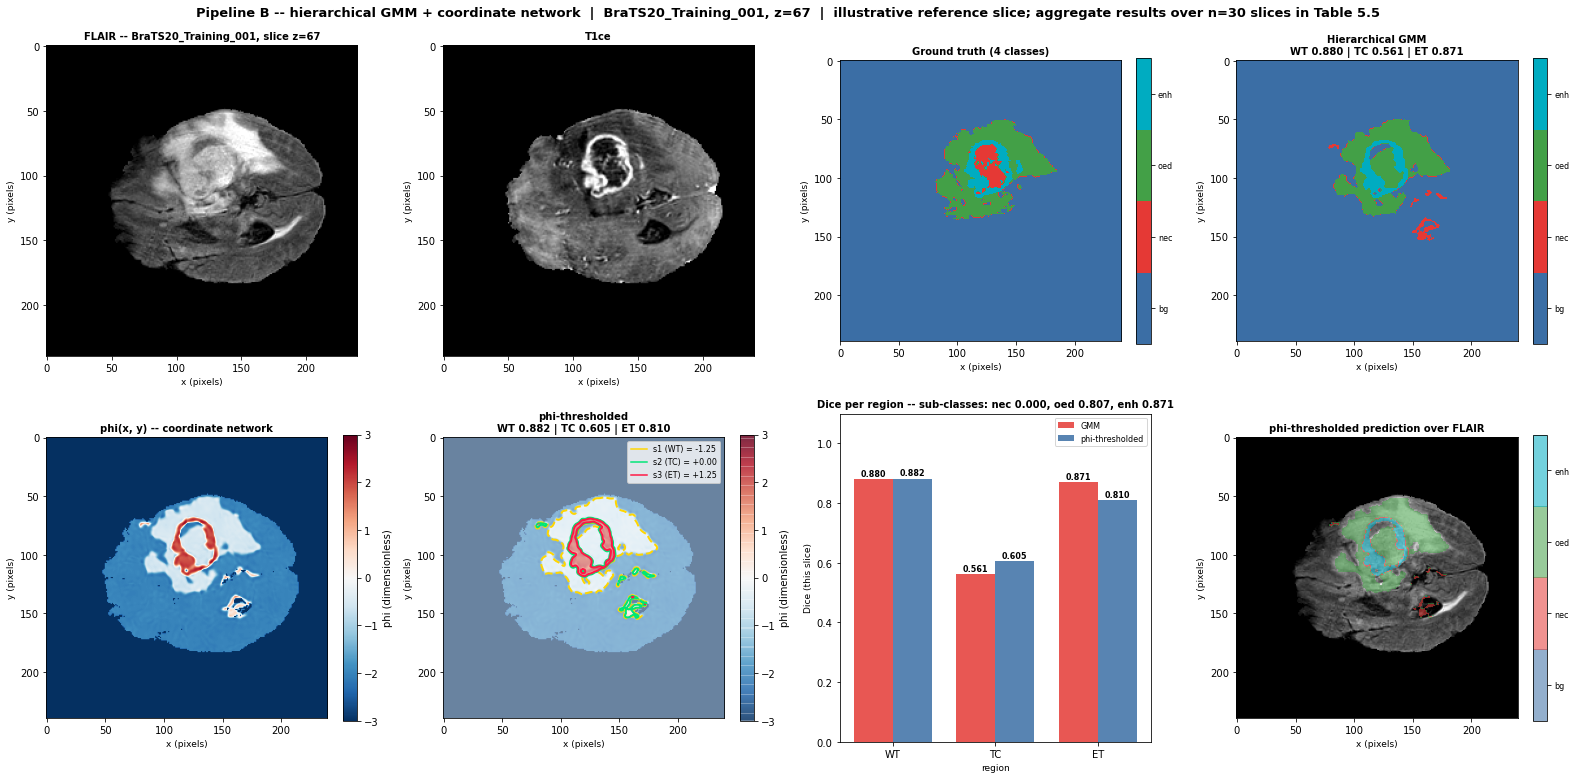

[fig] /kaggle/working/results/figures/fig_5_2_pipelineB.png


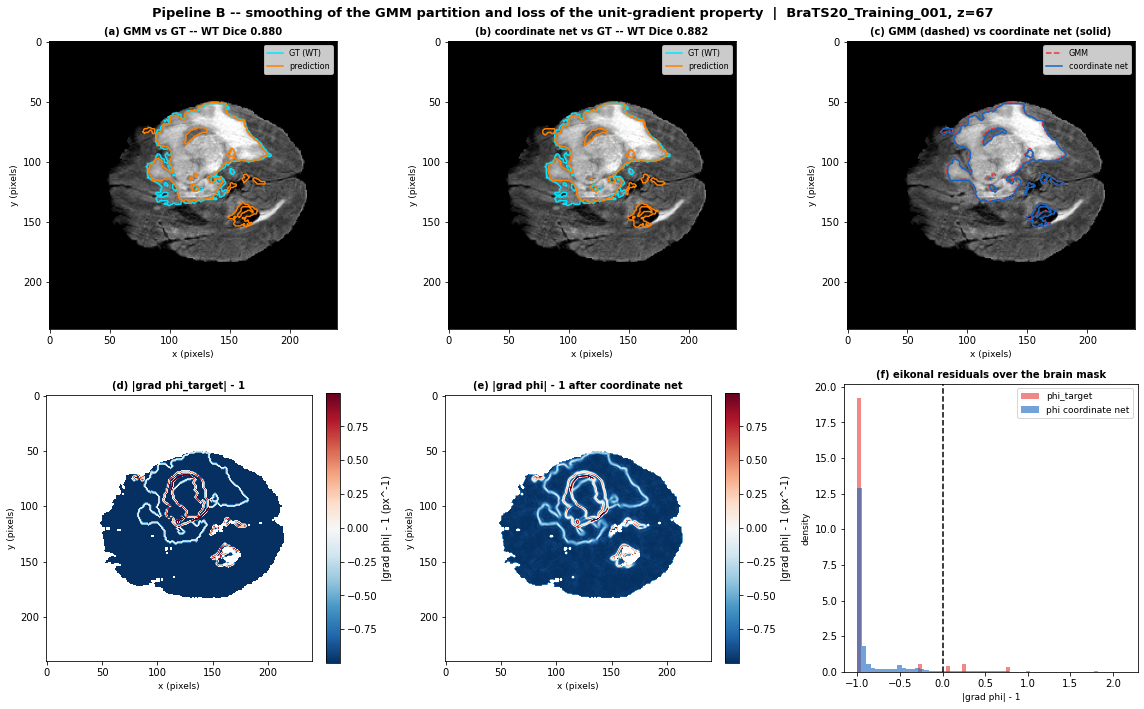

[fig] /kaggle/working/results/figures/fig_4_5_gmm_plane.png


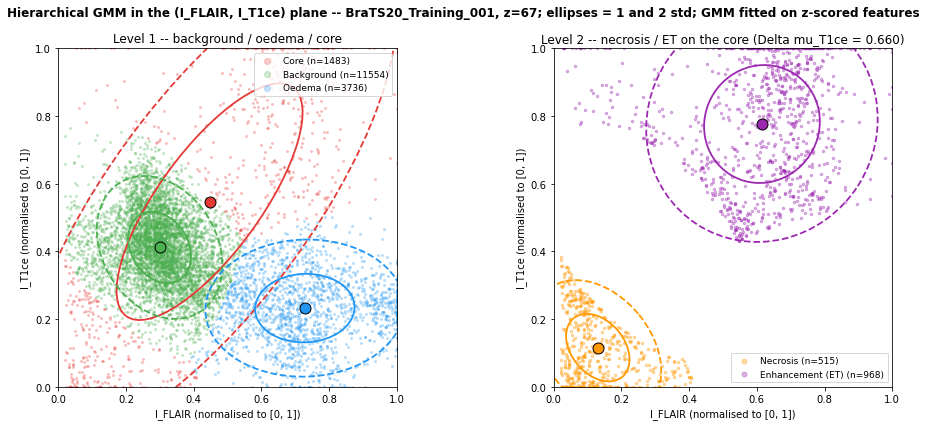

In [5]:
# ═══════════════════════════════════════════════════════════
# §B  PROTOCOL FILE [B2] + REFERENCE SLICE (Table 5.4) + SELF-SUFFICIENT FIGURES 5.4 / 5.2 / 4.5 [P2.6]
# ═══════════════════════════════════════════════════════════
import sklearn, scipy
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
protocol = {
    "config": config,
    "features": {"level1": "(I_FL, I_T1), z-scored", "level2": "(I_FL, I_T1" + (", x/W, y/H" if config["use_position"] else "") + "), z-scored"},
    "normalisation": "percentile [1,99] of non-zero voxels per volume -> [0,1]; brain mask I_FL > 0.02 after normalisation; native 240x240, no resize",
    "dice_empty_rule": "Dice := 1 if prediction and GT both empty; n_eff and class-present Dice reported alongside",
    "versions": {"torch": torch.__version__, "cuda": torch.version.cuda, "numpy": np.__version__, "sklearn": sklearn.__version__,
                 "scipy": scipy.__version__, "nibabel": nib.__version__,
                 "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"},
}
json.dump(protocol, open(f"{OUT}/protocol_pipelineB.json", "w"), indent=1, default=str)
if config["use_position"]:
    print("[B2] WARNING: level-2 GMM uses (x, y) position features. Fig. 4.5 and Algorithm 2 of the thesis describe "
          "a 2-D intensity feature space -> either set use_position=False or state the 4-D feature vector in §4.4.1.")

flair, t1ce, gt, slice_idx, name = load_brats(DATA_DIR, config["patient_id"], config["slice_idx"])
R = run_slice(flair, t1ce, gt, config)
print(f"\n  Table 5.4 -- {name}, slice z={slice_idx}  (GMM {R['t_gmm']:.1f}s, coordinate net {R['t_net']:.1f}s)")
print(f"    Sub-class Dice (GMM)          & {R['sub'][0]:.3f} & {R['sub'][1]:.3f} & {R['sub'][2]:.3f} \\\\")
print(f"    Region Dice (GMM)             & {R['reg']['WT']:.3f} & {R['reg']['TC']:.3f} & {R['reg']['ET']:.3f} \\\\")
print(f"    Region Dice (phi-thresholded) & {R['reg_phi']['WT']:.3f} & {R['reg_phi']['TC']:.3f} & {R['reg_phi']['ET']:.3f} \\\\")
print(f"    GT classes present: necrosis={R['gt_has_nec']} oedema={R['gt_has_oed']} enhancing={R['gt_has_enh']}; "
      f"core={R['core_px']} px, Delta mu_T1ce(enh-nec)={R['dmu_t1ce']:.3f}")

CMAP4 = ListedColormap(["#3b6ea5", "#E53935", "#43A047", "#00ACC1"])   # bg, necrosis, oedema, enhancing


def _axes(a):
    a.set_xlabel("x (pixels)", fontsize=9); a.set_ylabel("y (pixels)", fontsize=9)


def _class_colorbar(im, a):
    cb = plt.colorbar(im, ax=a, fraction=0.046, ticks=[0.375, 1.125, 1.875, 2.625])
    cb.ax.set_yticklabels(["bg", "nec", "oed", "enh"], fontsize=8)


def visualize(flair, t1ce, gt, R, name, z, n_eval, save):
    """Figure 5.4 -- self-sufficient: axes + units, colorbars, per-region Dice, slice ID, n."""
    seg, phi, seg_phi, sub, reg, rphi = R["seg"], R["phi"], R["seg_phi"], R["sub"], R["reg"], R["reg_phi"]
    fig, ax = plt.subplots(2, 4, figsize=(22, 11))
    for a in ax.ravel():
        _axes(a)
    ax[0, 0].imshow(flair, cmap="gray"); ax[0, 0].set_title(f"FLAIR -- {name}, slice z={z}", fontweight="bold", fontsize=10)
    ax[0, 1].imshow(t1ce, cmap="gray");  ax[0, 1].set_title("T1ce", fontweight="bold", fontsize=10)
    im = ax[0, 2].imshow(gt, cmap=CMAP4, vmin=0, vmax=3); ax[0, 2].set_title("Ground truth (4 classes)", fontweight="bold", fontsize=10); _class_colorbar(im, ax[0, 2])
    im = ax[0, 3].imshow(seg, cmap=CMAP4, vmin=0, vmax=3); _class_colorbar(im, ax[0, 3])
    ax[0, 3].set_title(f"Hierarchical GMM\nWT {reg['WT']:.3f} | TC {reg['TC']:.3f} | ET {reg['ET']:.3f}", fontweight="bold", fontsize=10)
    im = ax[1, 0].imshow(phi, cmap="RdBu_r", vmin=-3, vmax=3); ax[1, 0].set_title("phi(x, y) -- coordinate network", fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax[1, 0], fraction=0.046, label="phi (dimensionless)")
    im = ax[1, 1].imshow(phi, cmap="RdBu_r", vmin=-3, vmax=3, alpha=0.6)
    for s, col, lab in zip([config["s1"], config["s2"], config["s3"]], ["#FFD600", "#00E676", "#FF1744"], ["s1 (WT)", "s2 (TC)", "s3 (ET)"]):
        ax[1, 1].contour(phi, levels=[s], colors=[col], linewidths=2); ax[1, 1].plot([], [], color=col, label=f"{lab} = {s:+.2f}")
    ax[1, 1].legend(fontsize=8, loc="upper right")
    ax[1, 1].set_title(f"phi-thresholded\nWT {rphi['WT']:.3f} | TC {rphi['TC']:.3f} | ET {rphi['ET']:.3f}", fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax[1, 1], fraction=0.046, label="phi (dimensionless)")
    names = ["WT", "TC", "ET"]; x = np.arange(3); w = 0.38
    b1 = ax[1, 2].bar(x - w / 2, [reg[k] for k in names], w, label="GMM", color="#E53935", alpha=0.85)
    b2 = ax[1, 2].bar(x + w / 2, [rphi[k] for k in names], w, label="phi-thresholded", color="#3b6ea5", alpha=0.85)
    for bars in (b1, b2):
        for b in bars:
            ax[1, 2].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=8, fontweight="bold")
    ax[1, 2].set_xticks(x); ax[1, 2].set_xticklabels(names); ax[1, 2].set_ylim(0, 1.1); ax[1, 2].legend(fontsize=8)
    ax[1, 2].set_xlabel("region", fontsize=9); ax[1, 2].set_ylabel("Dice (this slice)", fontsize=9)
    ax[1, 2].set_title(f"Dice per region -- sub-classes: nec {sub[0]:.3f}, oed {sub[1]:.3f}, enh {sub[2]:.3f}", fontweight="bold", fontsize=10)
    ax[1, 3].imshow(flair, cmap="gray"); m = np.ma.masked_where(seg_phi == 0, seg_phi)
    im = ax[1, 3].imshow(m, cmap=CMAP4, vmin=0, vmax=3, alpha=0.55); _class_colorbar(im, ax[1, 3])
    ax[1, 3].set_title("phi-thresholded prediction over FLAIR", fontweight="bold", fontsize=10)
    fig.suptitle(f"Pipeline B -- hierarchical GMM + coordinate network  |  {name}, z={z}  |  illustrative reference slice; "
                 f"aggregate results over n={n_eval} slices in Table 5.5", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.savefig(save, dpi=200, bbox_inches="tight"); print(f"[fig] {save}"); plt.show(); plt.close(fig)


def eikonal_residual(phi, eps=1e-6):
    gy, gx = np.gradient(phi)
    return np.sqrt(gx ** 2 + gy ** 2 + eps) - 1.0


def plot_refinement(flair, gt, R, name, z, save):
    """Figure 5.2 -- GMM contour vs coordinate-net contour + eikonal residual, self-sufficient."""
    phi_t, phi, bm, seg, seg_phi = R["phi_t"], R["phi"], R["brain"], R["seg"], R["seg_phi"]
    d0, d1 = _dice_bin(seg > 0, gt > 0), _dice_bin(seg_phi > 0, gt > 0)
    r0, r1 = eikonal_residual(phi_t), eikonal_residual(phi); r0[~bm] = np.nan; r1[~bm] = np.nan
    vmax = np.nanpercentile(np.abs(np.concatenate([r0[bm], r1[bm]])), 98)
    fig, ax = plt.subplots(2, 3, figsize=(16, 10))
    for a in ax.ravel()[:5]:
        _axes(a)
    for a, s, t in [(ax[0, 0], seg, f"(a) GMM vs GT -- WT Dice {d0:.3f}"), (ax[0, 1], seg_phi, f"(b) coordinate net vs GT -- WT Dice {d1:.3f}")]:
        a.imshow(flair, cmap="gray"); a.contour(gt > 0, levels=[0.5], colors=["#00E5FF"], linewidths=1.5)
        a.contour(s > 0, levels=[0.5], colors=["#FF7F00"], linewidths=1.5)
        a.plot([], [], color="#00E5FF", label="GT (WT)"); a.plot([], [], color="#FF7F00", label="prediction"); a.legend(fontsize=8, loc="upper right")
        a.set_title(t, fontweight="bold", fontsize=10)
    ax[0, 2].imshow(flair, cmap="gray")
    ax[0, 2].contour(seg > 0, levels=[0.5], colors=["#E53935"], linewidths=1.2, linestyles="--"); ax[0, 2].contour(seg_phi > 0, levels=[0.5], colors=["#1565C0"], linewidths=1.5)
    ax[0, 2].plot([], [], "--", color="#E53935", label="GMM"); ax[0, 2].plot([], [], color="#1565C0", label="coordinate net"); ax[0, 2].legend(fontsize=8)
    ax[0, 2].set_title("(c) GMM (dashed) vs coordinate net (solid)", fontweight="bold", fontsize=10)
    for a, r, t in [(ax[1, 0], r0, "(d) |grad phi_target| - 1"), (ax[1, 1], r1, "(e) |grad phi| - 1 after coordinate net")]:
        im = a.imshow(r, cmap="RdBu_r", vmin=-vmax, vmax=vmax); a.set_title(t, fontweight="bold", fontsize=10)
        plt.colorbar(im, ax=a, fraction=0.046, label="|grad phi| - 1 (px^-1)")
    ax[1, 2].hist(r0[bm].ravel(), bins=60, alpha=0.6, density=True, color="#E53935", label="phi_target")
    ax[1, 2].hist(r1[bm].ravel(), bins=60, alpha=0.6, density=True, color="#1565C0", label="phi coordinate net")
    ax[1, 2].axvline(0, color="k", ls="--"); ax[1, 2].legend(fontsize=9); ax[1, 2].set_xlabel("|grad phi| - 1", fontsize=9); ax[1, 2].set_ylabel("density", fontsize=9)
    ax[1, 2].set_title("(f) eikonal residuals over the brain mask", fontweight="bold", fontsize=10)
    fig.suptitle(f"Pipeline B -- smoothing of the GMM partition and loss of the unit-gradient property  |  {name}, z={z}", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.savefig(save, dpi=200, bbox_inches="tight"); print(f"[fig] {save}"); plt.show(); plt.close(fig)


def plot_gmm_intensity_plane(flair, t1ce, brain_mask, cfg, name, z, save):
    """Figure 4.5 -- level-1 / level-2 clusters. Axes are the [0,1]-normalised intensities (the GMM is fitted on
    z-scored features; ellipses are re-estimated in the raw plane). Position features, if used, are not shown."""
    pts = np.column_stack([flair[brain_mask], t1ce[brain_mask]])
    lab1 = _gmm(3, cfg).fit(StandardScaler().fit_transform(pts)).predict(StandardScaler().fit_transform(pts))
    mfl = np.array([pts[lab1 == k, 0].mean() for k in range(3)]); mt1 = np.array([pts[lab1 == k, 1].mean() for k in range(3)])
    bg = int(np.argmin(mfl)); rest = [k for k in range(3) if k != bg]
    core_k = rest[int(np.argmax([mt1[k] for k in rest]))]; edema_k = [k for k in rest if k != core_k][0]
    names = {bg: "Background", edema_k: "Oedema", core_k: "Core"}; colors = {bg: "#4CAF50", edema_k: "#2196F3", core_k: "#E53935"}

    def ellipses(a, p, mu, col):
        cov = np.cov(p.T)
        for nsig, ls in [(1, "-"), (2, "--")]:
            vals, vecs = np.linalg.eigh(cov); order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1])); w, h = 2 * nsig * np.sqrt(np.maximum(vals, 1e-12))
            a.add_patch(Ellipse(mu, w, h, angle=theta, fill=False, edgecolor=col, lw=1.8, ls=ls))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    rng = np.random.default_rng(0); idx = rng.choice(len(pts), size=min(8000, len(pts)), replace=False)
    for k in range(3):
        m = lab1[idx] == k
        ax[0].scatter(pts[idx][m, 0], pts[idx][m, 1], s=4, alpha=0.25, c=colors[k], label=f"{names[k]} (n={int((lab1 == k).sum())})")
        mu = pts[lab1 == k].mean(0); ax[0].scatter(*mu, s=120, c=colors[k], edgecolors="k", zorder=5); ellipses(ax[0], pts[lab1 == k], mu, colors[k])
    core_pts = pts[lab1 == core_k]
    dmu = np.nan
    if len(core_pts) > cfg["min_core_pixels"]:
        lab2 = _gmm(2, cfg).fit_predict(StandardScaler().fit_transform(core_pts))   # intensity-only view of level 2
        m_t1 = [core_pts[lab2 == c, 1].mean() for c in range(2)]
        enh_k, nec_k = int(np.argmax(m_t1)), int(np.argmin(m_t1)); dmu = m_t1[enh_k] - m_t1[nec_k]
        c2 = {nec_k: "#FF9800", enh_k: "#9C27B0"}; n2 = {nec_k: "Necrosis", enh_k: "Enhancement (ET)"}
        for k in range(2):
            m = lab2 == k
            ax[1].scatter(core_pts[m, 0], core_pts[m, 1], s=6, alpha=0.35, c=c2[k], label=f"{n2[k]} (n={int(m.sum())})")
            mu = core_pts[m].mean(0); ax[1].scatter(*mu, s=120, c=c2[k], edgecolors="k", zorder=5); ellipses(ax[1], core_pts[m], mu, c2[k])
        ax[1].legend(markerscale=2, fontsize=9)
    for a, t in [(ax[0], "Level 1 -- background / oedema / core"), (ax[1], f"Level 2 -- necrosis / ET on the core (Delta mu_T1ce = {dmu:.3f})")]:
        a.set_xlabel("I_FLAIR (normalised to [0, 1])"); a.set_ylabel("I_T1ce (normalised to [0, 1])"); a.set_title(t)
        a.set_xlim(0, 1); a.set_ylim(0, 1); a.set_aspect("equal")
    ax[0].legend(markerscale=3, loc="upper right", fontsize=9)
    fig.suptitle(f"Hierarchical GMM in the (I_FLAIR, I_T1ce) plane -- {name}, z={z}; ellipses = 1 and 2 std; "
                 f"GMM fitted on z-scored features", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.savefig(save, dpi=200, bbox_inches="tight"); print(f"[fig] {save}"); plt.show(); plt.close(fig)


N_EVAL_PLACEHOLDER = "30"   # replaced by the real count after §C if you re-run this cell
visualize(flair, t1ce, gt, R, name, slice_idx, N_EVAL_PLACEHOLDER, f"{OUT}/figures/fig_5_4_pipelineB.png")
plot_refinement(flair, gt, R, name, slice_idx, f"{OUT}/figures/fig_5_2_pipelineB.png")
plot_gmm_intensity_plane(flair, t1ce, R["brain"], config, name, slice_idx, f"{OUT}/figures/fig_4_5_gmm_plane.png")


In [6]:
# ═══════════════════════════════════════════════════════════
# §C  MULTI-SLICE EVALUATION -> per-slice journal  [B1 one source of truth, B2 IDs, P1.10 prevalence, cost]
#      Resumable: (tag, patient, z) already in the CSV are skipped. phi maps saved for the threshold sweep (§E).
# ═══════════════════════════════════════════════════════════
N_PATIENTS, SLICES_PER_PATIENT, SLICE_STEP = 10, 3, 5
JOURNAL = f"{OUT}/pipelineB_slices.csv"
SWEEP_KEYS = ["use_position", "use_postprocess", "min_core_pixels", "gmm_n_init", "fourier_dim", "fourier_scale",
              "hidden", "epochs", "lr", "n_points", "phi_scale", "s1", "s2", "s3"]

grid = [
    ("reported",       {}),                                       # thesis configuration
    ("no_position",    {"use_position": False}),                  # ablation: 2-D intensity features only (as Algo. 2 states)
    ("no_postprocess", {"use_postprocess": False}),               # ablation: raw GMM partition
]

# slice selection rule [B2 / §7.3]: first N_PATIENTS patients in sorted order; for each, the reference slice
# (all three classes, largest area) and +-SLICE_STEP around it; slices with < 50 tumour pixels skipped.
pats = sorted([d for d in Path(DATA_DIR).iterdir() if d.is_dir()])[:N_PATIENTS]
eval_slices = []
for p in pats:
    _, _, _, base, _ = load_brats(DATA_DIR, p.name, None, verbose=False)
    for off in range(SLICES_PER_PATIENT):
        eval_slices.append((p.name, base + (off - SLICES_PER_PATIENT // 2) * SLICE_STEP))
json.dump({"rule": "first 10 patients (sorted), reference slice +- 5, skip if < 50 tumour px", "slices": eval_slices},
          open(f"{OUT}/eval_slices_pipelineB.json", "w"), indent=1)


def cfg_id(cfg):
    return hashlib.md5(json.dumps({k: str(cfg[k]) for k in SWEEP_KEYS}, sort_keys=True).encode()).hexdigest()[:8]


def load_journal():
    return pd.read_csv(JOURNAL) if os.path.exists(JOURNAL) else pd.DataFrame()


for tag, over in grid:
    cfg = {**config, **over}; cid = cfg_id(cfg)
    J = load_journal(); done = set(zip(J.tag, J.patient, J.z)) if len(J) else set()
    print(f"\n[{tag}] cfg {cid}")
    for pname, z in eval_slices:
        if (tag, pname, z) in done:
            continue
        try:
            fl, t1, g, z, _ = load_brats(DATA_DIR, pname, z, verbose=False)
            if g.sum() < 50:
                print(f"   [skip] {pname} z={z}: < 50 tumour px"); continue
            r = run_slice(fl, t1, g, cfg)
        except Exception as e:
            print(f"   [skip] {pname} z={z}: {type(e).__name__}: {e}"); continue
        row = {"tag": tag, "cfg_id": cid, "patient": pname, "z": z, "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
               "wt_px": int((g > 0).sum()), "nec_px": int((g == 1).sum()), "oed_px": int((g == 2).sum()), "enh_px": int((g == 3).sum()),
               "gt_has_nec": r["gt_has_nec"], "gt_has_oed": r["gt_has_oed"], "gt_has_enh": r["gt_has_enh"],
               "core_px": r["core_px"], "l2_fitted": r["l2_fitted"], "dmu_t1ce": r["dmu_t1ce"],
               "nec": r["sub"][0], "oed": r["sub"][1], "enh": r["sub"][2],
               "WT": r["reg"]["WT"], "TC": r["reg"]["TC"], "ET": r["reg"]["ET"],
               "WTp": r["reg_phi"]["WT"], "TCp": r["reg_phi"]["TC"], "ETp": r["reg_phi"]["ET"],
               "necp": r["sub_phi"][0], "oedp": r["sub_phi"][1], "enhp": r["sub_phi"][2],
               "t_gmm": round(r["t_gmm"], 2), "t_net": round(r["t_net"], 2),
               **{k: str(cfg[k]) for k in SWEEP_KEYS}}
        pd.DataFrame([row]).to_csv(JOURNAL, mode="a", index=False, header=not os.path.exists(JOURNAL))
        np.savez_compressed(f"{OUT}/phi/{tag}_{pname}_z{z}.npz", phi=r["phi"].astype(np.float32), gt=g.astype(np.int8), brain=r["brain"])
        print(f"   {pname} z={z:3d}: WT {row['WT']:.3f}->{row['WTp']:.3f} | TC {row['TC']:.3f}->{row['TCp']:.3f} | "
              f"ET {row['ET']:.3f}->{row['ETp']:.3f} | nec {row['nec']:.3f} (GT nec: {row['gt_has_nec']}) | {row['t_gmm']+row['t_net']:.0f}s")



[reported] cfg 3d930981

[no_position] cfg 1ac53d50
   BraTS20_Training_003 z= 68: WT 0.076->0.078 | TC 0.434->0.425 | ET 0.485->0.467 | nec 0.000 (GT nec: True) | 308s
   BraTS20_Training_003 z= 73: WT 0.096->0.097 | TC 0.328->0.354 | ET 0.559->0.532 | nec 0.000 (GT nec: True) | 317s
   BraTS20_Training_003 z= 78: WT 0.089->0.089 | TC 0.000->0.000 | ET 0.000->0.000 | nec 0.000 (GT nec: True) | 318s
   BraTS20_Training_004 z= 81: WT 0.858->0.857 | TC 0.690->0.708 | ET 0.859->0.821 | nec 0.317 (GT nec: True) | 319s
   BraTS20_Training_004 z= 86: WT 0.913->0.908 | TC 0.696->0.731 | ET 0.725->0.643 | nec 0.502 (GT nec: True) | 318s
   BraTS20_Training_004 z= 91: WT 0.964->0.963 | TC 0.753->0.778 | ET 0.789->0.724 | nec 0.558 (GT nec: True) | 317s
   BraTS20_Training_005 z= 90: WT 0.096->0.098 | TC 0.740->0.766 | ET 0.843->0.778 | nec 0.339 (GT nec: True) | 317s
   BraTS20_Training_005 z= 95: WT 0.350->0.365 | TC 0.915->0.885 | ET 0.380->0.308 | nec 0.615 (GT nec: True) | 318s
   BraTS20_


 TABLE 5.5 -- reported: n = 30 slices from 10 patients (mean ± std [median])
    Sub-class (GMM)        & $0.009 \pm 0.022$ [0.000] & $0.383 \pm 0.348$ [0.210] & $0.420 \pm 0.340$ [0.492] \\
    Region (GMM)           & $0.460 \pm 0.325$ [0.334] & $0.454 \pm 0.287$ [0.552] & $0.420 \pm 0.340$ [0.492] \\
    Region (phi-thresh)    & $0.459 \pm 0.324$ [0.339] & $0.465 \pm 0.296$ [0.580] & $0.411 \pm 0.328$ [0.537] \\
    necrosis  : GT present in n_eff = 29/30 slices; Dice on those slices (GMM) $0.009 \pm 0.022$ [0.000], (phi) $0.025 \pm 0.026$ [0.021]; both-empty slices counted as Dice=1: 0
    oedema    : GT present in n_eff = 30/30 slices; Dice on those slices (GMM) $0.383 \pm 0.348$ [0.210], (phi) $0.361 \pm 0.327$ [0.204]; both-empty slices counted as Dice=1: 0
    enhancing : GT present in n_eff = 29/30 slices; Dice on those slices (GMM) $0.434 \pm 0.337$ [0.528], (phi) $0.425 \pm 0.324$ [0.542]; both-empty slices counted as Dice=1: 0
    level-2 GMM fitted on 30/30 slices (core >

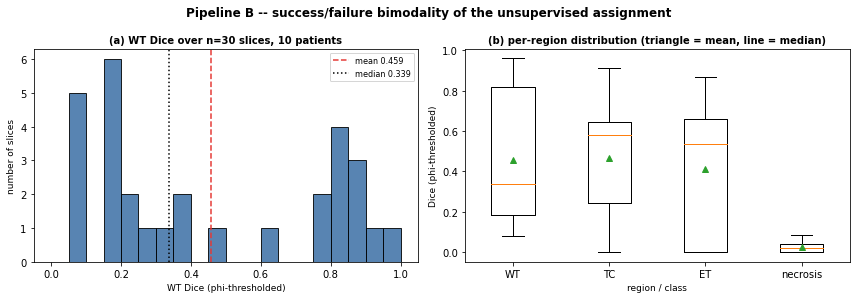

In [7]:
# ═══════════════════════════════════════════════════════════
# §D  TABLES 5.5 / 5.7 from the journal: mean ± std [median], n_eff per class, class-present Dice,
#      bimodality histogram [P1.10], ablations, cost per slice.
# ═══════════════════════════════════════════════════════════
J = load_journal()


def ms(v):
    v = np.asarray(v, float)
    return f"${v.mean():.3f} \\pm {v.std(ddof=1):.3f}$ [{np.median(v):.3f}]" if v.size > 1 else "n/a"


for tag in J.tag.unique():
    T = J[J.tag == tag]; n = len(T)
    print("\n" + "=" * 78 + f"\n TABLE 5.5 -- {tag}: n = {n} slices from {T.patient.nunique()} patients (mean ± std [median])\n" + "=" * 78)
    print(f"    Sub-class (GMM)        & {ms(T.nec)} & {ms(T.oed)} & {ms(T.enh)} \\\\")
    print(f"    Region (GMM)           & {ms(T.WT)} & {ms(T.TC)} & {ms(T.ET)} \\\\")
    print(f"    Region (phi-thresh)    & {ms(T.WTp)} & {ms(T.TCp)} & {ms(T.ETp)} \\\\")
    # [P1.10] prevalence and class-present Dice
    for cls, col, colp, has in [("necrosis", "nec", "necp", "gt_has_nec"), ("oedema", "oed", "oedp", "gt_has_oed"), ("enhancing", "enh", "enhp", "gt_has_enh")]:
        P = T[T[has] == True]
        print(f"    {cls:10s}: GT present in n_eff = {len(P)}/{n} slices; Dice on those slices (GMM) {ms(P[col])}, (phi) {ms(P[colp])}; "
              f"both-empty slices counted as Dice=1: {int(((T[has] == False) & (T[col] == 1.0)).sum())}")
    print(f"    level-2 GMM fitted on {int(T.l2_fitted.sum())}/{n} slices (core > {config['min_core_pixels']} px); "
          f"Delta mu_T1ce (enh - nec): median {T.dmu_t1ce.median():.3f}, min {T.dmu_t1ce.min():.3f}")
    print(f"    WT Dice (phi) < 0.5 on {int((T.WTp < 0.5).sum())}/{n} slices -> bimodal (see histogram)")
    print(f"    cost: GMM {T.t_gmm.mean():.1f} s/slice, coordinate net {T.t_net.mean():.1f} s/slice on {protocol['versions']['gpu']}")
    print(f"    Table 5.7 row (phi-thresholded, {n}-slice mean): WT {T.WTp.mean():.3f} & TC {T.TCp.mean():.3f} & ET {T.ETp.mean():.3f}")
    print(f"    best slice (WT, phi): {T.loc[T.WTp.idxmax(), 'patient']} z={int(T.loc[T.WTp.idxmax(), 'z'])} -> {T.WTp.max():.3f}  "
          f"(illustrative only; not comparable with a test-set Dice)")

# ablation summary (mean over slices)
A = J.groupby("tag")[["WT", "TC", "ET", "WTp", "TCp", "ETp", "nec"]].mean().round(3)
print("\n Ablation (means over slices):\n", A.to_string())

# [P1.10] histogram of the WT Dice distribution for the reported configuration
T = J[J.tag == "reported"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(T.WTp, bins=np.linspace(0, 1, 21), color="#3b6ea5", alpha=0.85, edgecolor="k")
ax[0].axvline(T.WTp.mean(), color="#E53935", ls="--", label=f"mean {T.WTp.mean():.3f}"); ax[0].axvline(T.WTp.median(), color="k", ls=":", label=f"median {T.WTp.median():.3f}")
ax[0].set_xlabel("WT Dice (phi-thresholded)", fontsize=9); ax[0].set_ylabel("number of slices", fontsize=9); ax[0].legend(fontsize=8)
ax[0].set_title(f"(a) WT Dice over n={len(T)} slices, {T.patient.nunique()} patients", fontsize=10, fontweight="bold")
ax[1].boxplot([T.WTp, T.TCp, T.ETp, T.necp], labels=["WT", "TC", "ET", "necrosis"], showmeans=True)
ax[1].set_ylabel("Dice (phi-thresholded)", fontsize=9); ax[1].set_xlabel("region / class", fontsize=9)
ax[1].set_title("(b) per-region distribution (triangle = mean, line = median)", fontsize=10, fontweight="bold")
fig.suptitle("Pipeline B -- success/failure bimodality of the unsupervised assignment", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{OUT}/figures/fig_pipelineB_distribution.png", dpi=200, bbox_inches="tight"); plt.show(); plt.close(fig)
J.to_csv(f"{OUT}/pipelineB_slices_snapshot.csv", index=False)


In [8]:
# ═══════════════════════════════════════════════════════════
# §E  THRESHOLD SENSITIVITY (Table 5.6) -- on the reference slice AND averaged over the evaluation slices,
#      from the saved phi maps. s1, s2 kept at their constructed values when sweeping s3 (and vice versa).
# ═══════════════════════════════════════════════════════════
S3_GRID = [0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
S2_GRID = [-0.75, -0.50, -0.25, 0.00, 0.25, 0.50]
S1_GRID = [-2.00, -1.50, -1.25, -1.00, -0.75, -0.50]
s1_0, s2_0, s3_0 = config["s1"], config["s2"], config["s3"]

files = sorted(Path(f"{OUT}/phi").glob("reported_*.npz"))
maps = [np.load(f) for f in files]
print(f"[E] {len(maps)} saved phi maps (reported config)")


def sweep(which, grid, region, items):
    rows = []
    for v in grid:
        s = {"s1": s1_0, "s2": s2_0, "s3": s3_0}; s[which] = v
        d = [dice_regions(phi_to_4regions(m["phi"], m["brain"], s["s1"], s["s2"], s["s3"]), m["gt"])[region] for m in items]
        rows.append((v, float(np.mean(d)), float(np.std(d, ddof=1)) if len(d) > 1 else 0.0))
    return rows


for which, grid_, region in [("s3", S3_GRID, "ET"), ("s2", S2_GRID, "TC"), ("s1", S1_GRID, "WT")]:
    ref = sweep(which, grid_, region, [{"phi": R["phi"], "brain": R["brain"], "gt": gt}])
    avg = sweep(which, grid_, region, maps)
    constr = {"s1": s1_0, "s2": s2_0, "s3": s3_0}[which]
    print(f"\n Table 5.6 -- Dice({region}) vs {which} (others fixed at s1={s1_0}, s2={s2_0}, s3={s3_0})")
    print(f"    ${which}$ & " + " & ".join(f"${v:.2f}$" for v, _, _ in avg) + r" \\")
    print(f"    reference slice {name} z={slice_idx} & " + " & ".join(f"${d:.3f}$" for _, d, _ in ref) + r" \\")
    print(f"    mean over {len(maps)} slices & " + " & ".join(f"${d:.3f} \\pm {sd:.3f}$" for _, d, sd in avg) + r" \\")
    b_ref, b_avg = max(ref, key=lambda r: r[1]), max(avg, key=lambda r: r[1])
    d_ref = dict((v, d) for v, d, _ in ref)[constr]; d_avg = dict((v, d) for v, d, _ in avg)[constr]
    print(f"    constructed {which}={constr:+.2f}: ref {d_ref:.3f}, mean {d_avg:.3f} | best: ref {which}={b_ref[0]:+.2f} ({b_ref[1]:.3f}), "
          f"mean {which}={b_avg[0]:+.2f} ({b_avg[1]:.3f}) -> gain {b_avg[1]-d_avg:+.3f} would require labels; midpoint rule retained (Remark 4.3)")


[E] 30 saved phi maps (reported config)

 Table 5.6 -- Dice(ET) vs s3 (others fixed at s1=-1.25, s2=0.0, s3=1.25)
    $s3$ & $0.50$ & $0.75$ & $1.00$ & $1.25$ & $1.50$ & $2.00$ \\
    reference slice BraTS20_Training_001 z=67 & $0.798$ & $0.817$ & $0.821$ & $0.810$ & $0.783$ & $0.518$ \\
    mean over 30 slices & $0.419 \pm 0.265$ & $0.409 \pm 0.312$ & $0.410 \pm 0.327$ & $0.411 \pm 0.328$ & $0.409 \pm 0.326$ & $0.327 \pm 0.261$ \\
    constructed s3=+1.25: ref 0.810, mean 0.411 | best: ref s3=+1.00 (0.821), mean s3=+0.50 (0.419) -> gain +0.009 would require labels; midpoint rule retained (Remark 4.3)

 Table 5.6 -- Dice(TC) vs s2 (others fixed at s1=-1.25, s2=0.0, s3=1.25)
    $s2$ & $-0.75$ & $-0.50$ & $-0.25$ & $0.00$ & $0.25$ & $0.50$ \\
    reference slice BraTS20_Training_001 z=67 & $0.459$ & $0.517$ & $0.603$ & $0.605$ & $0.602$ & $0.606$ \\
    mean over 30 slices & $0.259 \pm 0.232$ & $0.297 \pm 0.250$ & $0.449 \pm 0.285$ & $0.465 \pm 0.296$ & $0.467 \pm 0.301$ & $0.468 \pm 0.

In [9]:
# ═══════════════════════════════════════════════════════════
# §F  Environment freeze for the repository (Appendix A)
# ═══════════════════════════════════════════════════════════
!pip freeze > /kaggle/working/results/requirements_pipelineB.txt
print(open("/kaggle/working/results/protocol_pipelineB.json").read()[:1500])


{
 "config": {
  "patient_id": "BraTS20_Training_001",
  "slice_idx": 67,
  "gmm_n_init": 10,
  "gmm_max_iter": 400,
  "gmm_tol": 0.001,
  "gmm_reg_covar": 1e-06,
  "gmm_seed": 42,
  "min_core_pixels": 20,
  "use_position": true,
  "use_postprocess": true,
  "use_coordnet": true,
  "torch_seed": 42,
  "phi_scale": 3.0,
  "fourier_scale": 4.0,
  "fourier_dim": 32,
  "hidden": [
   128,
   256,
   256,
   128
  ],
  "epochs": 500,
  "lr": 0.001,
  "batch_size": 8192,
  "n_points": 60000,
  "sample_seed": 42,
  "s1": -1.25,
  "s2": 0.0,
  "s3": 1.25,
  "brain_threshold": 0.02
 },
 "features": {
  "level1": "(I_FL, I_T1), z-scored",
  "level2": "(I_FL, I_T1, x/W, y/H), z-scored"
 },
 "normalisation": "percentile [1,99] of non-zero voxels per volume -> [0,1]; brain mask I_FL > 0.02 after normalisation; native 240x240, no resize",
 "dice_empty_rule": "Dice := 1 if prediction and GT both empty; n_eff and class-present Dice reported alongside",
 "versions": {
  "torch": "1.7.0",
  "cuda": "10.